📊 Dataset caricato: 50 immagini, 1082 annotazioni

🔬 Paziente Virtuale (50 campi):
Totale celle: 1082

Conteggi per tipo:
  epithelial          :   503 → Grado AICNA: ++++
  neutrophil          :   323 → Grado AICNA: ++++
  eosinophil          :    54 → Grado AICNA: ++++
  muciparous          :    51 → Grado AICNA: +
  metaplastic         :    23 → Grado AICNA: +
  epithelial ciliated :    11 → Grado AICNA: +
  lymphocyte          :    11 → Grado AICNA: +++
  mast cell           :     2 → Grado AICNA: +

🏥 Endotipo classificato: NARNE


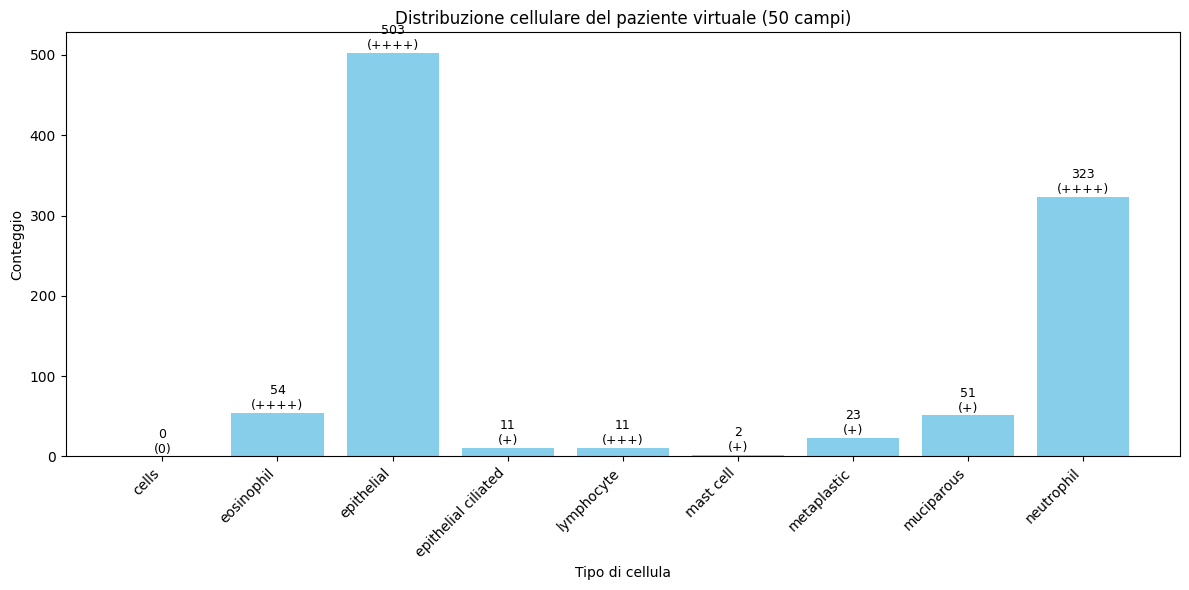


✅ Grafico salvato in: results/distribuzione_paziente_virtuale.png


In [1]:
# 03_metriche_cliniche.ipynb
# 
# SCOPO: Questo notebook implementa e testa le metriche cliniche per la tesi:
#        "Oltre il mAP: metriche di validazione cito-cliniche per il rilevamento 
#        automatico di citotipi nasali"
#
# AUTORE: Mirko Patruno
# DATA:   Agosto 2026
# CORRELATRICE: Prof.ssa Nunzia Lomonte
#
# Le metriche cliniche qui implementate saranno poi utilizzate per confrontare
# i tre modelli (YOLOv10, RT-DETR, EfficientDet) e verificare se il ranking
# cambia passando da metriche di detection a metriche cliniche.
#
# RIFERIMENTI:
# - Macchi et al., "Standardization of Nasal Cytology: An Expert-based Delphi Consensus", 2026
# - Gelardi, "Nasal cytology in the rhinology-allergy clinic", 2025

import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 1. DEFINIZIONE DELLE CLASSI CLINICHE E DELLE SOGLIE
# ============================================================================

# Mappa delle classi del dataset (da annotations.json)
# Nota: i nomi sono quelli originali del dataset, con spazi
CLINICAL_CLASSES = {
    'epithelial': 4,
    'neutrophil': 10,
    'eosinophil': 3,
    'mast cell': 7,
    'lymphocyte': 6,
    'muciparous': 9,      # Cellule caliciformi
    'metaplastic': 8,
    'epithelial ciliated': 5,
    'emazia': 2,          # Eritrociti - DA ESCLUDERE
    'artefatto': 1,       # Artefatti - DA ESCLUDERE
}

# Classi clinicamente rilevanti (escluse emazia e artefatto)
CLINICAL_CELL_TYPES = [k for k in CLINICAL_CLASSES.keys() if k not in ['emazia', 'artefatto']]

# Classi patologiche (assenti nel soggetto sano secondo il Delphi Consensus)
PATHOLOGICAL_CELLS = ['eosinophil', 'mast cell', 'lymphocyte']

# ============================================================================
# 2. GRIGLIA SEMI-QUANTITATIVA AICNA (Tabella 2.13 della tesi Camporeale)
# ============================================================================
# 
# La griglia AICNA trasforma i conteggi assoluti in gradi semi-quantitativi:
# Grado 0: assente
# Grado +: rara
# Grado ++: occasionale
# Grado +++: numerosa
# Grado ++++: molto numerosa
#
# Riferimento: Macchi et al., 2026 - Delphi Consensus

AICNA_THRESHOLDS = {
    'epithelial': {'+': (1, 100), '++': (101, 200), '+++': (201, 300), '++++': (301, float('inf'))},
    'neutrophil': {'+': (1, 20), '++': (21, 40), '+++': (41, 100), '++++': (101, float('inf'))},
    'eosinophil': {'+': (1, 5), '++': (6, 10), '+++': (11, 30), '++++': (31, float('inf'))},
    'mast cell': {'+': (1, 5), '++': (6, 10), '+++': (11, 30), '++++': (31, float('inf'))},
    'lymphocyte': {'+': (1, 5), '++': (6, 10), '+++': (11, 30), '++++': (31, float('inf'))},
    'muciparous': {'+': (1, 100), '++': (101, 200), '+++': (201, 300), '++++': (301, float('inf'))},
    'metaplastic': {'+': (1, 100), '++': (101, 200), '+++': (201, 300), '++++': (301, float('inf'))},
    'epithelial ciliated': {'+': (1, 100), '++': (101, 200), '+++': (201, 300), '++++': (301, float('inf'))},
}

# ============================================================================
# 3. FUNZIONI PER LE METRICHE CLINICHE
# ============================================================================

def get_aicna_grade(cell_type: str, count: int) -> str:
    """
    Calcola il grado semi-quantitativo AICNA per un tipo di cellula.
    
    Args:
        cell_type (str): Tipo di cellula (es. 'eosinophil', 'neutrophil')
        count (int): Conteggio assoluto della cellula
    
    Returns:
        str: Grado AICNA ('0', '+', '++', '+++', '++++')
    
    Esempio:
        >>> get_aicna_grade('eosinophil', 15)
        '+++'
    """
    thresholds = AICNA_THRESHOLDS.get(cell_type)
    if thresholds is None:
        return '0'
    
    if count == 0:
        return '0'
    
    for grade, (low, high) in thresholds.items():
        if low <= count <= high:
            return grade
    return '++++'

def classify_endotype(cell_counts: dict) -> str:
    """
    Classifica l'endotipo del paziente in base ai conteggi cellulari.
    
    Segue le definizioni dell'Accademia Italiana di Citologia Nasale (AICNA):
    - NARES: Rinite Non Allergica a Eosinofili
    - NARMA: Rinite Non Allergica a Mastociti
    - NARESMA: Rinite Non Allergica a Eosinofili e Mastociti
    - NARNE: Rinite Non Allergica a Neutrofili
    
    Args:
        cell_counts (dict): Conteggi per tipo di cellula
    
    Returns:
        str: Endotipo classificato
    
    Riferimenti:
    - Gelardi, 2025: "Nasal cytology in the rhinology-allergy clinic"
    - Macchi et al., 2026: Delphi Consensus
    """
    total = sum(cell_counts.values())
    if total == 0:
        return 'normal'
    
    eos = cell_counts.get('eosinophil', 0)
    mast = cell_counts.get('mast cell', 0)
    neut = cell_counts.get('neutrophil', 0)
    
    eos_pct = eos / total
    mast_pct = mast / total
    neut_pct = neut / total
    
    # Soglie diagnostiche (da Gelardi, 2025)
    if eos_pct > 0.10:
        return 'allergic_rhinitis'
    elif eos_pct > 0.05 and mast_pct > 0.05:
        return 'naresma'          # Forma più severa
    elif eos_pct > 0.05:
        return 'nares'            # Eosinofili dominanti
    elif mast_pct > 0.05:
        return 'narma'            # Mastociti dominanti
    elif neut_pct > 0.10:
        return 'narne'            # Neutrofili dominanti
    else:
        return 'normal'

# ============================================================================
# 4. TEST SUL DATASET NMCD
# ============================================================================

def load_dataset_annotations(split: str = 'valid'):
    """
    Carica le annotazioni del dataset NMCD per uno split specifico.
    
    Args:
        split (str): 'train', 'valid', o 'test'
    
    Returns:
        dict: Dizionario con le annotazioni COCO
    """
    data_dir = Path('../data/NMCD.coco')
    ann_file = data_dir / split / '_annotations.coco.json'
    
    if not ann_file.exists():
        raise FileNotFoundError(f"File non trovato: {ann_file}")
    
    with open(ann_file, 'r') as f:
        return json.load(f)

# Carica il dataset di validazione (per test rapido)
data = load_dataset_annotations('valid')
print(f"📊 Dataset caricato: {len(data['images'])} immagini, {len(data['annotations'])} annotazioni")

# Mappa delle categorie
cat_map = {cat['id']: cat['name'] for cat in data['categories']}

# ============================================================================
# 5. AGGREGAZIONE PER PAZIENTE VIRTUALE (50 CAMPIONI)
# ============================================================================

def create_virtual_patient(annotations, images, n_samples=50):
    """
    Crea un paziente virtuale aggregando N campioni microscopici.
    
    Il protocollo clinico standard prevede l'analisi di 50 campi
    per vetrino (Delphi Consensus, 2026).
    
    Args:
        annotations (list): Lista di annotazioni COCO
        images (list): Lista di informazioni sulle immagini
        n_samples (int): Numero di campi da aggregare (default: 50)
    
    Returns:
        dict: Conteggi aggregati per tipo di cellula
    """
    # Prendi le prime N immagini (simula un paziente)
    patient_images = images[:n_samples]
    image_ids = [img['id'] for img in patient_images]
    
    # Conta le celle per ogni immagine
    counts = {cat_name: 0 for cat_name in cat_map.values()}
    
    for ann in annotations:
        if ann['image_id'] in image_ids:
            cat_name = cat_map[ann['category_id']]
            counts[cat_name] += 1
    
    return counts

# Crea un paziente virtuale con 50 campi
virtual_patient = create_virtual_patient(data['annotations'], data['images'], n_samples=50)

# Mostra i conteggi
print("\n🔬 Paziente Virtuale (50 campi):")
print(f"Totale celle: {sum(virtual_patient.values())}")
print("\nConteggi per tipo:")
for cell_type, count in sorted(virtual_patient.items(), key=lambda x: -x[1]):
    if count > 0 and cell_type not in ['emazia', 'artefatto']:
        grade = get_aicna_grade(cell_type, count)
        print(f"  {cell_type:20s}: {count:5d} → Grado AICNA: {grade}")

# Classifica l'endotipo
endotype = classify_endotype(virtual_patient)
print(f"\n🏥 Endotipo classificato: {endotype.upper()}")

# ============================================================================
# 6. VISUALIZZAZIONE DEI RISULTATI (CORRETTA)
# ============================================================================

# Prepara i dati per il grafico
clinical_counts = {k: v for k, v in virtual_patient.items() 
                   if k not in ['emazia', 'artefatto']}

plt.figure(figsize=(12, 6))
bars = plt.bar(clinical_counts.keys(), clinical_counts.values(), color='skyblue')
plt.title('Distribuzione cellulare del paziente virtuale (50 campi)')
plt.xlabel('Tipo di cellula')
plt.ylabel('Conteggio')
plt.xticks(rotation=45, ha='right')

# Aggiungi i valori sopra le barre
for bar, (cell_type, count) in zip(bars, clinical_counts.items()):
    grade = get_aicna_grade(cell_type, count)  # ← USA cell_type, NON bar.get_text()!
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{count}\n({grade})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/distribuzione_paziente_virtuale.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Grafico salvato in: results/distribuzione_paziente_virtuale.png")